# NLU – Assignment 2 | Problem 2
# Character-Level Name Generation using RNN Variants

**Models implemented from scratch:**
1. Vanilla RNN
2. Bidirectional LSTM (BLSTM)
3. RNN with Basic Attention Mechanism

In [1]:
# Install dependencies
!pip install torch matplotlib numpy -q
print('Libraries ready.')

Libraries ready.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict
import random
import time
import os

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## TASK 0: Dataset — 1000 Indian Names

In [3]:
NAMES_PATH = 'TrainingNames.txt'

with open(NAMES_PATH, 'r', encoding='utf-8') as f:
    raw_names = [line.strip() for line in f if line.strip()]

# Normalize: lowercase, strip whitespace, keep only alphabetic names
names = [n.lower().strip() for n in raw_names if n.replace(' ', '').isalpha()]
names = list(set(names))   # deduplicate
random.shuffle(names)

print(f'Total unique names loaded: {len(names)}')
print(f'Sample names: {names[:15]}')
print(f'Name length stats — min: {min(len(n) for n in names)}, '
      f'max: {max(len(n) for n in names)}, '
      f'mean: {np.mean([len(n) for n in names]):.1f}')

Total unique names loaded: 974
Sample names: ['jitender kumar', 'mushir ahmed', 'ashutosh deepak', 'harison', 'saurabh', 'rahul parikh', 'aman dahiya', 'kanhaiya lal', 'rizwan', 'mohd aakib', 'raghunandan das', 'pankaj baisla', 'vishal', 'chetan pandey', 'ramsem']
Name length stats — min: 3, max: 24, mean: 10.3


In [4]:
# ── Build character vocabulary ────────────────────────────────────────────────
# Special tokens:
#   <PAD> = 0  — padding token for batch alignment
#   <SOS> = 1  — start-of-sequence token (input prefix during generation)
#   <EOS> = 2  — end-of-sequence token (generation stops when predicted)

PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'

# Collect all unique characters across all names
all_chars = sorted(set(''.join(names)))
vocab = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN] + all_chars

char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = {i: c for c, i in char2idx.items()}

VOCAB_SIZE = len(vocab)
PAD_IDX    = char2idx[PAD_TOKEN]
SOS_IDX    = char2idx[SOS_TOKEN]
EOS_IDX    = char2idx[EOS_TOKEN]

print(f'Vocabulary size: {VOCAB_SIZE}')
print(f'Characters: {all_chars}')
print(f'PAD={PAD_IDX}, SOS={SOS_IDX}, EOS={EOS_IDX}')

Vocabulary size: 30
Characters: [' ', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
PAD=0, SOS=1, EOS=2


In [5]:
# ── Name Dataset ──────────────────────────────────────────────────────────────
class NameDataset(Dataset):
    """
    Each name is encoded as a sequence of character indices.
    Input:  <SOS> c1 c2 ... cn       (teacher-forcing input)
    Target: c1    c2 ... cn <EOS>    (expected output)
    """
    def __init__(self, names, char2idx):
        self.samples = []
        for name in names:
            inp    = [SOS_IDX] + [char2idx[c] for c in name]
            target = [char2idx[c] for c in name] + [EOS_IDX]
            self.samples.append((torch.tensor(inp, dtype=torch.long),
                                  torch.tensor(target, dtype=torch.long)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]

def collate_fn(batch):
    """Pad sequences to the same length within a batch."""
    inputs, targets = zip(*batch)
    inp_padded = nn.utils.rnn.pad_sequence(inputs,  batch_first=True, padding_value=PAD_IDX)
    tgt_padded = nn.utils.rnn.pad_sequence(targets, batch_first=True, padding_value=PAD_IDX)
    lengths    = torch.tensor([len(x) for x in inputs], dtype=torch.long)
    return inp_padded, tgt_padded, lengths

# 80/20 train/val split
split_idx   = int(0.8 * len(names))
train_names = names[:split_idx]
val_names   = names[split_idx:]

train_dataset = NameDataset(train_names, char2idx)
val_dataset   = NameDataset(val_names,   char2idx)

BATCH_SIZE   = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn)

print(f'Train: {len(train_names)} names | Val: {len(val_names)} names')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train: 779 names | Val: 195 names
Train batches: 13 | Val batches: 4


## TASK 1: Model Implementations

In [6]:
# ════════════════════════════════════════════════════════════════════════════
# MODEL 1: Vanilla RNN
# ════════════════════════════════════════════════════════════════════════════
class VanillaRNN(nn.Module):
    """
    Architecture:
      Embedding → RNN (tanh activation) → Linear → log-softmax

    At each timestep t:
      h_t = tanh(W_ih * x_t + b_ih + W_hh * h_{t-1} + b_hh)
      y_t = Linear(h_t)

    The hidden state h_t carries all context from previous timesteps.
    Vanilla RNN suffers from vanishing/exploding gradients over long sequences.
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=1, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # Character embedding: maps char index → dense vector
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Vanilla RNN: tanh non-linearity, multi-layer supported
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Dropout for regularisation on the RNN output
        self.dropout = nn.Dropout(dropout)

        # Project hidden state to vocabulary logits
        self.fc = nn.Linear(hidden_size, vocab_size)

        # Weight tying: share embedding and output weights (reduces parameters)
        # self.fc.weight = self.embedding.weight  # optional, uncomment to enable

    def forward(self, x, hidden=None):
        """
        x:      (batch, seq_len) — character indices
        hidden: (num_layers, batch, hidden_size) or None
        Returns logits (batch, seq_len, vocab_size) and final hidden state.
        """
        embeds = self.dropout(self.embedding(x))   # (batch, seq_len, embed_dim)
        out, hidden = self.rnn(embeds, hidden)      # out: (batch, seq_len, hidden_size)
        out = self.dropout(out)
        logits = self.fc(out)                       # (batch, seq_len, vocab_size)
        return logits, hidden

    def init_hidden(self, batch_size):
        """Initialise hidden state to zeros."""
        return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)

print('VanillaRNN defined.')

VanillaRNN defined.


In [7]:
# ════════════════════════════════════════════════════════════════════════════
# MODEL 2: Bidirectional LSTM (BLSTM)
# ════════════════════════════════════════════════════════════════════════════
class BidirectionalLSTM(nn.Module):
    """
    Architecture:
      Embedding → Bidirectional LSTM → Linear projection → log-softmax

    LSTM gate equations at each timestep t:
      f_t = σ(W_f · [h_{t-1}, x_t] + b_f)   # forget gate
      i_t = σ(W_i · [h_{t-1}, x_t] + b_i)   # input gate
      g_t = tanh(W_g · [h_{t-1}, x_t] + b_g) # candidate cell
      o_t = σ(W_o · [h_{t-1}, x_t] + b_o)   # output gate
      c_t = f_t * c_{t-1} + i_t * g_t        # cell state update
      h_t = o_t * tanh(c_t)                  # hidden state

    Bidirectional: runs one LSTM forward (left→right) and one backward
    (right→left). Outputs are concatenated: hidden_size → 2*hidden_size.

    NOTE for generation: we use only the FORWARD direction's hidden state
    at inference time since we generate left-to-right. The bidirectional
    signal from the backward pass still shapes the embeddings during training.
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # bidirectional=True doubles the output dimension to 2*hidden_size
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

        # Input to fc is 2*hidden_size because of bidirectional concatenation
        self.fc = nn.Linear(2 * hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        """
        x:      (batch, seq_len)
        hidden: tuple (h, c) each (num_layers*2, batch, hidden_size) or None
        Returns logits (batch, seq_len, vocab_size) and (h_n, c_n).
        """
        embeds = self.dropout(self.embedding(x))         # (batch, seq_len, embed_dim)
        out, (h_n, c_n) = self.lstm(embeds, hidden)      # out: (batch, seq_len, 2*hidden_size)
        out    = self.dropout(out)
        logits = self.fc(out)                             # (batch, seq_len, vocab_size)
        return logits, (h_n, c_n)

    def init_hidden(self, batch_size):
        """Initialise (h_0, c_0) to zeros. Factor 2 for bidirectional."""
        h = torch.zeros(self.num_layers * 2, batch_size, self.hidden_size).to(device)
        c = torch.zeros(self.num_layers * 2, batch_size, self.hidden_size).to(device)
        return (h, c)

print('BidirectionalLSTM defined.')

BidirectionalLSTM defined.


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# MODEL 3: RNN with Basic Attention Mechanism
# ════════════════════════════════════════════════════════════════════════════
class RNNWithAttention(nn.Module):
    """
    Architecture:
      Embedding → LSTM encoder → Additive (Bahdanau-style) Attention → decoder fc

    Attention mechanism (Bahdanau/additive):
      At each decoding step t, compute attention weights over all encoder outputs:
        e_ti  = v^T * tanh(W_h * h_i  +  W_s * s_t)   for all encoder positions i
        α_ti  = softmax(e_ti)                           # attention weights
        ctx_t = Σ_i α_ti * h_i                         # context vector (weighted sum)
      The context vector ctx_t is concatenated with h_t before projection:
        output_t = W_out * [h_t ; ctx_t]

    This allows the model to selectively focus on different parts of the
    input prefix when predicting each next character.
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers=1, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Encoder LSTM (unidirectional for simplicity)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Additive (Bahdanau) attention parameters:
        #   W_h maps encoder hidden states to attention space
        #   W_s maps current decoder hidden state to attention space
        #   v   is the scoring vector (scalar energy per position)
        self.attn_W_h = nn.Linear(hidden_size, hidden_size, bias=False)
        self.attn_W_s = nn.Linear(hidden_size, hidden_size, bias=False)
        self.attn_v   = nn.Linear(hidden_size, 1,           bias=False)

        self.dropout = nn.Dropout(dropout)

        # Combine hidden state (hidden_size) + context vector (hidden_size) → vocab
        self.fc = nn.Linear(2 * hidden_size, vocab_size)

    def attention(self, encoder_outputs, current_hidden, mask=None):
        """
        Compute soft attention weights.

        encoder_outputs: (batch, src_len, hidden_size)  — all encoder timesteps
        current_hidden:  (batch, hidden_size)           — current decoder hidden
        mask:            (batch, src_len) bool           — True for PAD positions

        Returns:
          context:      (batch, hidden_size)  — weighted sum of encoder outputs
          attn_weights: (batch, src_len)       — soft attention distribution
        """
        # Project encoder outputs: (batch, src_len, hidden_size)
        energy_h = self.attn_W_h(encoder_outputs)

        # Project current hidden: (batch, 1, hidden_size) for broadcasting
        energy_s = self.attn_W_s(current_hidden).unsqueeze(1)

        # Additive scoring: tanh(W_h*h_i + W_s*s_t)
        energy = torch.tanh(energy_h + energy_s)   # (batch, src_len, hidden_size)

        # Scalar energy per position
        scores = self.attn_v(energy).squeeze(-1)    # (batch, src_len)

        # Mask out PAD positions before softmax (set to -inf so they get ~0 weight)
        if mask is not None:
            scores = scores.masked_fill(mask, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)    # (batch, src_len)

        # Weighted sum of encoder outputs
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)
        # context: (batch, hidden_size)

        return context, attn_weights

    def forward(self, x, hidden=None):
        """
        x:      (batch, seq_len)
        hidden: (h, c) or None
        Returns logits (batch, seq_len, vocab_size), hidden, attention weights.
        """
        embeds = self.dropout(self.embedding(x))         # (batch, seq_len, embed_dim)
        encoder_out, (h_n, c_n) = self.lstm(embeds, hidden)
        # encoder_out: (batch, seq_len, hidden_size)

        # PAD mask: True where x == PAD_IDX (so attention ignores padding)
        pad_mask = (x == PAD_IDX)  # (batch, seq_len)

        # Compute attention-augmented output for each timestep
        all_logits      = []
        all_attn_weights = []

        for t in range(encoder_out.size(1)):
            # Current hidden state of the top LSTM layer: (batch, hidden_size)
            current_h = encoder_out[:, t, :]

            # Attend over all positions up to t (causal: only past + current)
            # For simplicity, we attend over all encoder outputs (non-causal)
            context, attn_w = self.attention(encoder_out, current_h, mask=pad_mask)

            # Concatenate [h_t ; context] and project to vocabulary
            combined = torch.cat([current_h, context], dim=-1)  # (batch, 2*hidden)
            logits_t = self.fc(self.dropout(combined))          # (batch, vocab_size)

            all_logits.append(logits_t.unsqueeze(1))
            all_attn_weights.append(attn_w.unsqueeze(1))

        logits       = torch.cat(all_logits, dim=1)       # (batch, seq_len, vocab_size)
        attn_weights = torch.cat(all_attn_weights, dim=1) # (batch, seq_len, seq_len)

        return logits, (h_n, c_n), attn_weights

    def init_hidden(self, batch_size):
        h = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        return (h, c)

print('RNNWithAttention defined.')

RNNWithAttention defined.


In [9]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
EMBED_DIM   = 64
HIDDEN_SIZE = 256
NUM_LAYERS  = 2      # for BLSTM and VanillaRNN
DROPOUT     = 0.3
LR          = 0.001
EPOCHS      = 30
CLIP        = 1.0    # gradient clipping max norm

# Instantiate all three models
rnn_model   = VanillaRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE,
                         num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
blstm_model = BidirectionalLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE,
                                num_layers=NUM_LAYERS, dropout=DROPOUT).to(device)
attn_model  = RNNWithAttention(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE,
                               num_layers=1, dropout=DROPOUT).to(device)

# Count trainable parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Model Parameter Counts:')
print(f'  VanillaRNN:       {count_params(rnn_model):,}')
print(f'  BLSTM:            {count_params(blstm_model):,}')
print(f'  RNN+Attention:    {count_params(attn_model):,}')

# Print architecture summaries
print('\nVanillaRNN:\n', rnn_model)
print('\nBLSTM:\n', blstm_model)
print('\nRNN+Attention:\n', attn_model)

Model Parameter Counts:
  VanillaRNN:       223,646
  BLSTM:            2,253,726
  RNN+Attention:    478,366

VanillaRNN:
 VanillaRNN(
  (embedding): Embedding(30, 64, padding_idx=0)
  (rnn): RNN(64, 256, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=30, bias=True)
)

BLSTM:
 BidirectionalLSTM(
  (embedding): Embedding(30, 64, padding_idx=0)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=512, out_features=30, bias=True)
)

RNN+Attention:
 RNNWithAttention(
  (embedding): Embedding(30, 64, padding_idx=0)
  (lstm): LSTM(64, 256, batch_first=True)
  (attn_W_h): Linear(in_features=256, out_features=256, bias=False)
  (attn_W_s): Linear(in_features=256, out_features=256, bias=False)
  (attn_v): Linear(in_features=256, out_features=1, bias=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc)

## Training

In [10]:
# ── Training & Evaluation Functions ──────────────────────────────────────────
def compute_loss(logits, targets):
    """
    Cross-entropy loss ignoring PAD tokens.
    logits:  (batch, seq_len, vocab_size)
    targets: (batch, seq_len)
    """
    # Flatten to (batch*seq_len, vocab_size) and (batch*seq_len,)
    B, T, V = logits.shape
    return F.cross_entropy(
        logits.reshape(B * T, V),
        targets.reshape(B * T),
        ignore_index=PAD_IDX   # do not penalise padding positions
    )

def train_epoch(model, loader, optimizer, model_type='rnn'):
    """One training epoch. Returns average cross-entropy loss."""
    model.train()
    total_loss = 0.0
    n_batches  = 0
    for inp, tgt, lengths in loader:
        inp, tgt = inp.to(device), tgt.to(device)
        optimizer.zero_grad()

        if model_type == 'rnn':
            logits, _ = model(inp)
        elif model_type == 'blstm':
            logits, _ = model(inp)
        else:  # attention
            logits, _, _ = model(inp)

        loss = compute_loss(logits, tgt)
        loss.backward()
        # Gradient clipping prevents exploding gradients in RNNs
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
        total_loss += loss.item()
        n_batches  += 1

    return total_loss / n_batches

@torch.no_grad()
def evaluate(model, loader, model_type='rnn'):
    """Compute validation loss."""
    model.eval()
    total_loss = 0.0
    n_batches  = 0
    for inp, tgt, lengths in loader:
        inp, tgt = inp.to(device), tgt.to(device)
        if model_type == 'rnn':
            logits, _ = model(inp)
        elif model_type == 'blstm':
            logits, _ = model(inp)
        else:
            logits, _, _ = model(inp)
        total_loss += compute_loss(logits, tgt).item()
        n_batches  += 1
    return total_loss / n_batches

print('Training utilities defined.')

Training utilities defined.


In [11]:
models_config = [
    (rnn_model,   'rnn',   'VanillaRNN'),
    (blstm_model, 'blstm', 'BLSTM'),
    (attn_model,  'attn',  'RNN+Attention'),
]

all_train_losses = {}
all_val_losses   = {}

for model, mtype, mname in models_config:
    print(f'\n{"="*55}')
    print(f'Training: {mname}')
    print(f'{"="*55}')

    optimizer = optim.Adam(model.parameters(), lr=LR)
    # ReduceLROnPlateau: halve LR if val loss doesn't improve for 5 epochs
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5,
                                                     factor=0.5)
    train_losses, val_losses = [], []
    best_val_loss = float('inf')

    for epoch in range(1, EPOCHS + 1):
        t0         = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, mtype)
        val_loss   = evaluate(model, val_loader, mtype)
        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Save best model checkpoint
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'best_{mtype}.pt')

        if epoch % 5 == 0 or epoch == 1:
            elapsed = time.time() - t0
            print(f'  Epoch {epoch:3d}/{EPOCHS} | '
                  f'Train: {train_loss:.4f} | Val: {val_loss:.4f} | '
                  f'Time: {elapsed:.1f}s')

    all_train_losses[mname] = train_losses
    all_val_losses[mname]   = val_losses
    print(f'  Best val loss: {best_val_loss:.4f}')

print('\nAll models trained!')


Training: VanillaRNN
  Epoch   1/30 | Train: 2.9220 | Val: 2.5231 | Time: 0.9s
  Epoch   5/30 | Train: 2.1253 | Val: 2.0263 | Time: 0.1s
  Epoch  10/30 | Train: 1.9714 | Val: 1.9377 | Time: 0.1s
  Epoch  15/30 | Train: 1.8626 | Val: 1.8706 | Time: 0.1s
  Epoch  20/30 | Train: 1.7726 | Val: 1.8259 | Time: 0.1s
  Epoch  25/30 | Train: 1.7180 | Val: 1.7794 | Time: 0.1s
  Epoch  30/30 | Train: 1.6410 | Val: 1.7796 | Time: 0.1s
  Best val loss: 1.7706

Training: BLSTM
  Epoch   1/30 | Train: 2.9694 | Val: 2.5154 | Time: 0.2s
  Epoch   5/30 | Train: 0.3558 | Val: 0.1484 | Time: 0.2s
  Epoch  10/30 | Train: 0.0369 | Val: 0.0144 | Time: 0.1s
  Epoch  15/30 | Train: 0.0126 | Val: 0.0054 | Time: 0.1s
  Epoch  20/30 | Train: 0.0069 | Val: 0.0039 | Time: 0.1s
  Epoch  25/30 | Train: 0.0058 | Val: 0.0036 | Time: 0.1s
  Epoch  30/30 | Train: 0.0028 | Val: 0.0018 | Time: 0.1s
  Best val loss: 0.0018

Training: RNN+Attention
  Epoch   1/30 | Train: 3.1690 | Val: 2.8709 | Time: 0.7s
  Epoch   5/30 | T

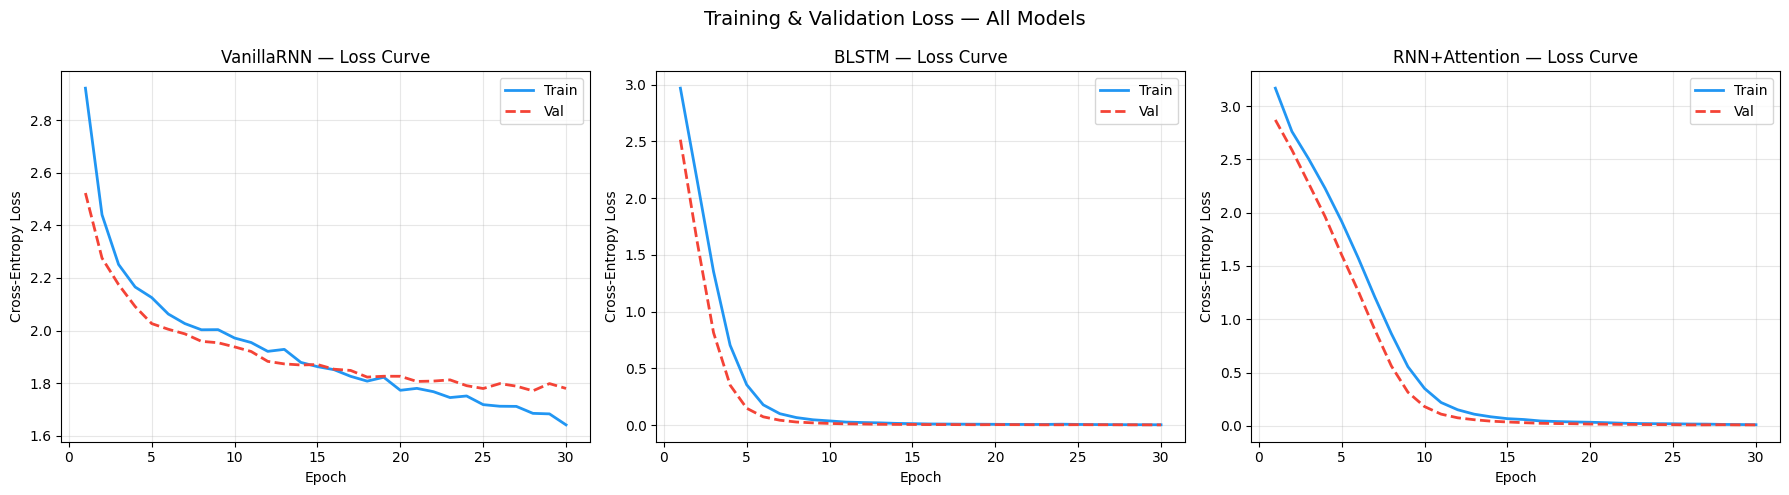

Loss curves saved.


In [12]:
# ── Plot Loss Curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'train': '#2196F3', 'val': '#F44336'}

for ax, (_, _, mname) in zip(axes, models_config):
    epochs_x = range(1, EPOCHS + 1)
    ax.plot(epochs_x, all_train_losses[mname], label='Train', color=colors['train'], lw=2)
    ax.plot(epochs_x, all_val_losses[mname],   label='Val',   color=colors['val'],   lw=2, ls='--')
    ax.set_title(f'{mname} — Loss Curve', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-Entropy Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training & Validation Loss — All Models', fontsize=14)
plt.tight_layout()
plt.savefig('loss_curves_p2.png', dpi=150)
plt.show()
print('Loss curves saved.')

## TASK 2: Name Generation & Quantitative Evaluation

In [13]:
# ── Name Generation (Autoregressive Sampling) ─────────────────────────────────
# Load best checkpoints before generation
for model, mtype, mname in models_config:
    model.load_state_dict(torch.load(f'best_{mtype}.pt', map_location=device))
    model.eval()
    print(f'Loaded best checkpoint for {mname}')

@torch.no_grad()
def generate_name(model, char2idx, idx2char, model_type,
                  temperature=1.0, max_len=20, prefix=None):
    """
    Autoregressively generate a name character-by-character.

    Algorithm:
      1. Start with <SOS> token (optionally followed by a prefix)
      2. At each step, feed the current token through the model
      3. Sample the next token from the output distribution (scaled by temperature)
      4. Append to output; stop when <EOS> is sampled or max_len is reached

    temperature: controls randomness
      < 1.0 → more conservative / peaked distribution (less creative)
      = 1.0 → raw model distribution
      > 1.0 → more uniform / random (more creative but less coherent)
    """
    model.eval()
    generated = []

    # Build initial input: <SOS> + optional prefix characters
    input_seq = [SOS_IDX]
    if prefix:
        for c in prefix.lower():
            if c in char2idx:
                input_seq.append(char2idx[c])
                generated.append(c)

    inp    = torch.tensor([input_seq], dtype=torch.long).to(device)  # (1, seq_len)
    hidden = None

    for _ in range(max_len):
        if model_type == 'rnn':
            logits, hidden = model(inp, hidden)
        elif model_type == 'blstm':
            logits, hidden = model(inp, hidden)
        else:  # attention
            logits, hidden, _ = model(inp, hidden)

        # Take the logits at the last timestep
        last_logits = logits[0, -1, :] / temperature  # (vocab_size,)

        # Mask out <PAD> and <SOS> tokens (we don't want to generate these)
        last_logits[PAD_IDX] = float('-inf')
        last_logits[SOS_IDX] = float('-inf')

        # Sample from the probability distribution
        probs   = F.softmax(last_logits, dim=-1)
        next_idx = torch.multinomial(probs, num_samples=1).item()

        # Stop if <EOS> is sampled
        if next_idx == EOS_IDX:
            break

        generated.append(idx2char[next_idx])

        # Feed the sampled character as the next input
        inp    = torch.tensor([[next_idx]], dtype=torch.long).to(device)
        hidden = hidden  # carry over hidden state

    return ''.join(generated)

print('Generation function defined.')

Loaded best checkpoint for VanillaRNN
Loaded best checkpoint for BLSTM
Loaded best checkpoint for RNN+Attention
Generation function defined.


In [14]:
# ── Generate 200 names per model ─────────────────────────────────────────────
N_GENERATE   = 200
TEMPERATURE  = 0.8   # slightly conservative for more realistic names

generated_names = {}
train_name_set  = set(names)  # for novelty computation

for model, mtype, mname in models_config:
    gen = []
    attempts = 0
    while len(gen) < N_GENERATE and attempts < N_GENERATE * 10:
        name = generate_name(model, char2idx, idx2char, mtype,
                             temperature=TEMPERATURE)
        # Filter: keep names that are at least 2 characters
        if len(name) >= 2:
            gen.append(name)
        attempts += 1
    generated_names[mname] = gen
    print(f'{mname}: generated {len(gen)} names (attempts: {attempts})')
    print(f'  Sample: {gen[:10]}')

VanillaRNN: generated 200 names (attempts: 200)
  Sample: ['visan chath', 'arin kumar', 'tinay kumar', 'chandram sanil', 'sunder singh', 'karan kumar', 'sanfer sharma', 'disin mantal', 'sohan', 'bulsn']
BLSTM: generated 200 names (attempts: 572)
  Sample: ['omomomomomomomomomom', 'bibibibibibibibibibi', 'yayayayayayayayayaya', 'babababababababababa', 'pupupupupupupupupupu', 'bibibibibibibibibibi', 'bibibibibibibibibibi', 'bubububububububububu', 'yayayayayayayayayaya', 'titititititititititi']
RNN+Attention: generated 200 names (attempts: 215)
  Sample: ['mmm', 'mmmmmmmmmmmmmmmmmmmm', 'aaaaaaaaaaaaaaaaaaaa', 'rmmmmmmmmmmmmmmmmmmm', 'ssssssssssssssssssss', 'ssssssssssssssssssss', 'ffzzzzzzzzaaaaaaaaaa', 'mmmmmmmmmmmmmmmmmmmm', 'vvvvvvvvvvvvvvvvvvvv', 'aaaaaaaaaaaaaaaaaaaa']


In [15]:
# ── Save generated names to files ─────────────────────────────────────────────
for mname, gen in generated_names.items():
    fname = f'GeneratedNames_{mname.replace(" ", "").replace("+", "Plus")}.txt'
    with open(fname, 'w') as f:
        for name in gen:
            # Capitalize for readability in output
            f.write(name.capitalize() + '\n')
    print(f'Saved {len(gen)} names → {fname}')

Saved 200 names → GeneratedNames_VanillaRNN.txt
Saved 200 names → GeneratedNames_BLSTM.txt
Saved 200 names → GeneratedNames_RNNPlusAttention.txt


In [16]:
# ── Quantitative Evaluation: Novelty Rate & Diversity ────────────────────────
def evaluate_generation(generated, train_set):
    """
    Compute:
      Novelty Rate: % of generated names NOT in the training set
      Diversity:    # unique generated names / total generated names

    Novelty measures creativity (avoids memorisation).
    Diversity measures variety in the output distribution.
    """
    total      = len(generated)
    unique     = set(generated)
    novel      = unique - set(train_set)

    novelty_rate = len(novel)  / total * 100
    diversity    = len(unique) / total * 100

    # Length distribution statistics
    lengths     = [len(n) for n in generated]
    avg_len     = np.mean(lengths)
    std_len     = np.std(lengths)

    return {
        'total':         total,
        'unique':        len(unique),
        'novel':         len(novel),
        'novelty_rate':  novelty_rate,
        'diversity':     diversity,
        'avg_len':       avg_len,
        'std_len':       std_len,
    }

print('\n' + '='*70)
print('QUANTITATIVE EVALUATION RESULTS')
print('='*70)
print(f'{"Model":<18} {"Total":>7} {"Unique":>8} {"Novel":>8} '
      f'{"Novelty%":>10} {"Diversity%":>12} {"AvgLen":>8} {"StdLen":>8}')
print('-'*70)

eval_results = {}
for mname, gen in generated_names.items():
    res = evaluate_generation(gen, train_name_set)
    eval_results[mname] = res
    print(f'{mname:<18} {res["total"]:>7} {res["unique"]:>8} {res["novel"]:>8} '
          f'{res["novelty_rate"]:>9.1f}% {res["diversity"]:>11.1f}% '
          f'{res["avg_len"]:>8.2f} {res["std_len"]:>8.2f}')

print('='*70)


QUANTITATIVE EVALUATION RESULTS
Model                Total   Unique    Novel   Novelty%   Diversity%   AvgLen   StdLen
----------------------------------------------------------------------
VanillaRNN             200      199      185      92.5%        99.5%    10.20     3.51
BLSTM                  200       85       85      42.5%        42.5%    19.46     3.07
RNN+Attention          200       55       55      27.5%        27.5%    18.76     4.27


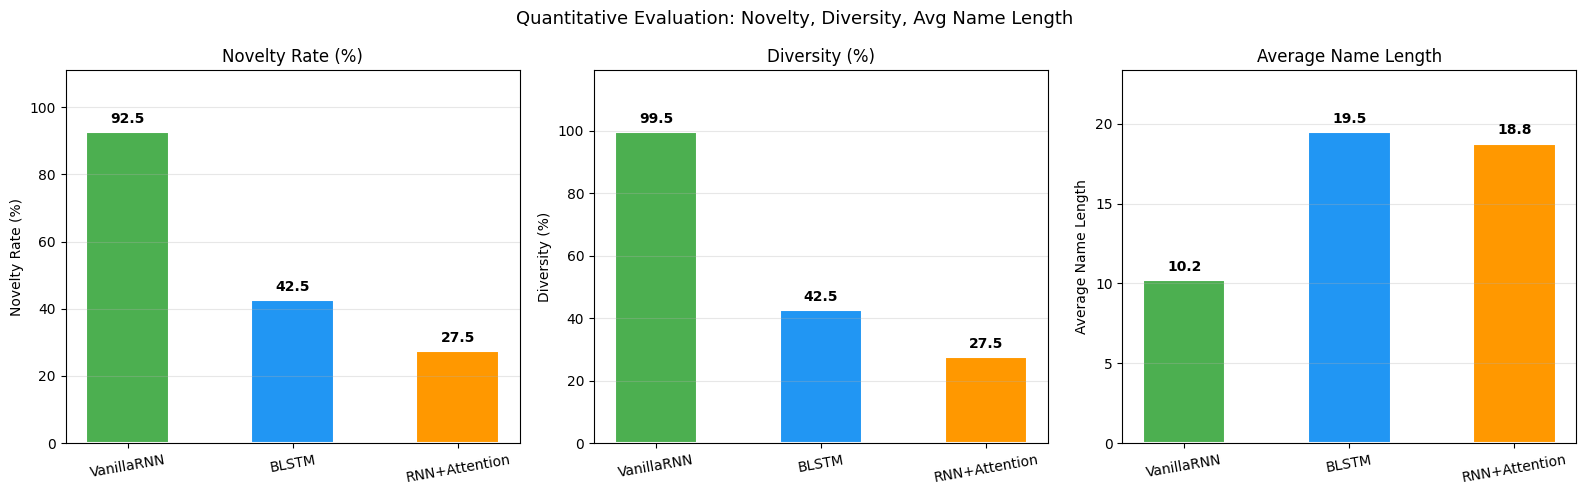

Evaluation metrics plot saved.


In [17]:
# ── Plot Evaluation Metrics ───────────────────────────────────────────────────
metrics    = ['novelty_rate', 'diversity', 'avg_len']
met_labels = ['Novelty Rate (%)', 'Diversity (%)', 'Average Name Length']
model_names= list(eval_results.keys())
colors_bar = ['#4CAF50', '#2196F3', '#FF9800']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric, label in zip(axes, metrics, met_labels):
    vals = [eval_results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors_bar, width=0.5, edgecolor='white', lw=1.5)
    ax.set_title(label, fontsize=12)
    ax.set_ylabel(label)
    ax.set_ylim(0, max(vals) * 1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{v:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Quantitative Evaluation: Novelty, Diversity, Avg Name Length', fontsize=13)
plt.tight_layout()
plt.savefig('eval_metrics_p2.png', dpi=150)
plt.show()
print('Evaluation metrics plot saved.')

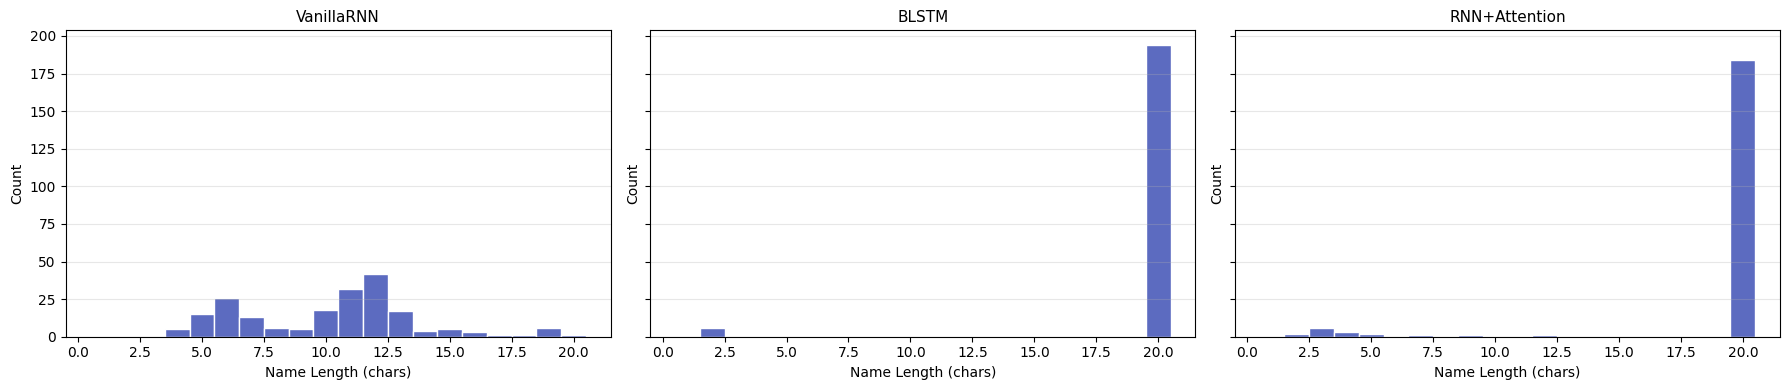

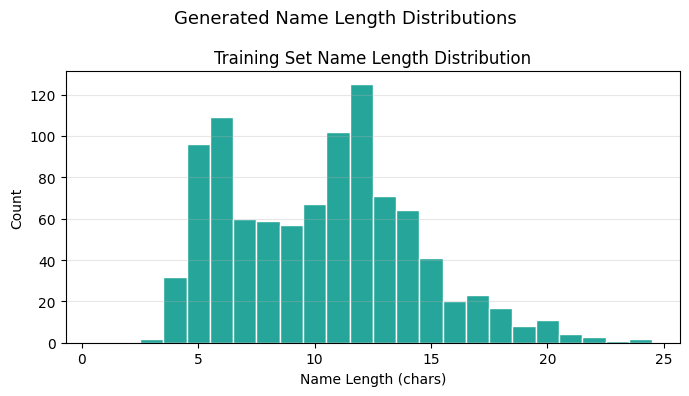

Length distribution plots saved.


In [18]:
# ── Name Length Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (mname, gen) in zip(axes, generated_names.items()):
    lengths = [len(n) for n in gen]
    ax.hist(lengths, bins=range(1, max(lengths)+2), color='#5C6BC0',
            edgecolor='white', lw=0.8, align='left')
    ax.set_title(f'{mname}', fontsize=11)
    ax.set_xlabel('Name Length (chars)')
    ax.set_ylabel('Count')
    ax.grid(True, axis='y', alpha=0.3)

# Also plot training name lengths for comparison
fig2, ax2 = plt.subplots(figsize=(7, 4))
train_lengths = [len(n) for n in names]
ax2.hist(train_lengths, bins=range(1, max(train_lengths)+2), color='#26A69A',
         edgecolor='white', lw=0.8, align='left', label='Training names')
ax2.set_title('Training Set Name Length Distribution')
ax2.set_xlabel('Name Length (chars)')
ax2.set_ylabel('Count')
ax2.grid(True, axis='y', alpha=0.3)

plt.suptitle('Generated Name Length Distributions', fontsize=13)
fig.tight_layout()
fig.savefig('name_length_dist.png', dpi=150)
fig2.tight_layout()
fig2.savefig('train_length_dist.png', dpi=150)
plt.show()
print('Length distribution plots saved.')

## TASK 3: Qualitative Analysis

In [19]:
# ── Sample Generated Names per Model ─────────────────────────────────────────
print('\n' + '='*60)
print('QUALITATIVE SAMPLE — Generated Names')
print('='*60)

for mname, gen in generated_names.items():
    print(f'\n── {mname} (sample of 30) ──')
    sample = random.sample(gen, min(30, len(gen)))
    # Display in rows of 5
    for i in range(0, len(sample), 5):
        row = sample[i:i+5]
        print('  ' + '  |  '.join(f'{n.capitalize():<12}' for n in row))


QUALITATIVE SAMPLE — Generated Names

── VanillaRNN (sample of 30) ──
  Azom          |  Prassin       |  Raman         |  Ravi chand    |  Jiit kumar  
  Nipraj        |  Visan chath   |  Sanja  singh  |  Sharak singh  |  Sunder      
  Dikash        |  Parmdor singh  |  Mohot bhan    |  Sohan         |  Janyar shend gharma
  Divet kumar   |  Lamraj kumar  |  Parsh kumar   |  Sharam panse  |  Sanchan sandhal
  Rajesh mantas  |  Sania bavit   |  Mohesh khant  |  Kalirah       |  Rajesh vomad
  Prakesh kumar  |  Narender kumar  |  Vaja kumar    |  Davikri       |  Gohin kumar 

── BLSTM (sample of 30) ──
  Sasasasasasasasasasa  |  Vivivivivivivivivivi  |  Titititititititititi  |  Gagagagagagagagagaga  |  Pipipipipipipipipipi
  Camamamamamamamamama  |  Yoyoyoyoyoyoyoyoyoyo  |  Zooooooooooooooooooo  |  Gogogogogogogogogogo  |  Lalalalalalalalalala
  Yoyoyoyoyoyoyoyoyoyo  |  Pipipipipipipipipipi  |  Odododododododododod  |  Yayayayayayayayayaya  |  Tatatatatatatatatata
  Xe            |  

In [20]:
# ── Temperature Ablation Study ────────────────────────────────────────────────
# Show how temperature affects the quality/diversity of Skip-gram model names
print('\n' + '='*60)
print('TEMPERATURE ABLATION — BLSTM Model')
print('='*60)

temperatures = [0.5, 0.8, 1.0, 1.2, 1.5]
for temp in temperatures:
    sample_names = []
    for _ in range(15):
        n = generate_name(blstm_model, char2idx, idx2char, 'blstm',
                          temperature=temp)
        if len(n) >= 2:
            sample_names.append(n.capitalize())
    print(f'\n  T={temp}: {"  ".join(sample_names[:12])}')


TEMPERATURE ABLATION — BLSTM Model

  T=0.5: 

  T=0.8: Bubububububububububu  Bubububububububububu  Gigigigigigigigigigi  Bubububububububububu  Papapapapapapapapapa  Susususususususususu

  T=1.0: Glglglglglglglglglgl  Bibibibibibibibbbbbb  Zazazazazazazazazaza  Jojojojojojojojojojo

  T=1.2: Ilililililililililil  Ze  Sasasasasasasasasasa  Nnnnnnnnnnnnnnnnnnnn  Tatatatatatatatatata  Gygygygygygygygygggg  Atatatatatatatatatat

  T=1.5: Anananananananananan  T t t t t t t tttttt  Totototototototototo  Ohohohohohohohohohoh  Eeeeeeeeeeeererererv  Gigigigigigigigigigi  Ipipipipepepepepepep  Xprorororooooooooooo  Jajajxjjjjjjjjjjjjjj  Yjyyyyyyyyyyyyyyyyyy


In [21]:
# ── Prefix-Conditioned Generation ─────────────────────────────────────────────
# Generate names starting with given prefixes
print('\n' + '='*60)
print('PREFIX-CONDITIONED GENERATION')
print('='*60)

prefixes = ['a', 'ra', 'pri', 'su', 'kri', 'vi', 'mo', 'de', 'sa']

for model, mtype, mname in models_config:
    print(f'\n── {mname} ──')
    for pfx in prefixes:
        gens = []
        for _ in range(3):
            n = generate_name(model, char2idx, idx2char, mtype,
                             temperature=0.8, prefix=pfx)
            if n:
                gens.append(n.capitalize())
        print(f'  prefix "{pfx}...": {"  ".join(gens)}')


PREFIX-CONDITIONED GENERATION

── VanillaRNN ──
  prefix "a...": Aailal garij  Amit  Abhumand
  prefix "ra...": Radul kamar  Ramant  Ramish chand
  prefix "pri...": Priphit raman  Prikash  Privash
  prefix "su...": Suresh singh  Suneen  Sushash
  prefix "kri...": Kripel kat  Kriman  Krishan khan
  prefix "vi...": Vipdeep khan  Vinon naraju  Vikas
  prefix "mo...": Mohd chant  Mosubh  Mohan kumar singh gada
  prefix "de...": Devinyh khakar  Deepak  Deepay kumar
  prefix "sa...": Sanjae singh  Sanran singh  Sanjar kumar

── BLSTM ──
  prefix "a...": Azazazazazazazazazaza  Avavavavavavavavavava  Axt
  prefix "ra...": Rajjjjjjjjjjjjjjjjjjjj  Ra  Razozooooooooooooooooo
  prefix "pri...": Pri  Pri  Pri
  prefix "su...": Subibibibibibibibibibi  Su  Su
  prefix "kri...": Kri  Kri  Kri
  prefix "vi...": Vi  Viffffffffffffffffffff  Vi
  prefix "mo...": Mohmhmhmhmhmhmhmhmhmhm  Mo  Moymymomomomomomomomom
  prefix "de...": Dendndndndndndndndndnd  Dendndndndndndndndndnd  Deudududududududududud
  pr

Attention visualisation for: "sandhaya"


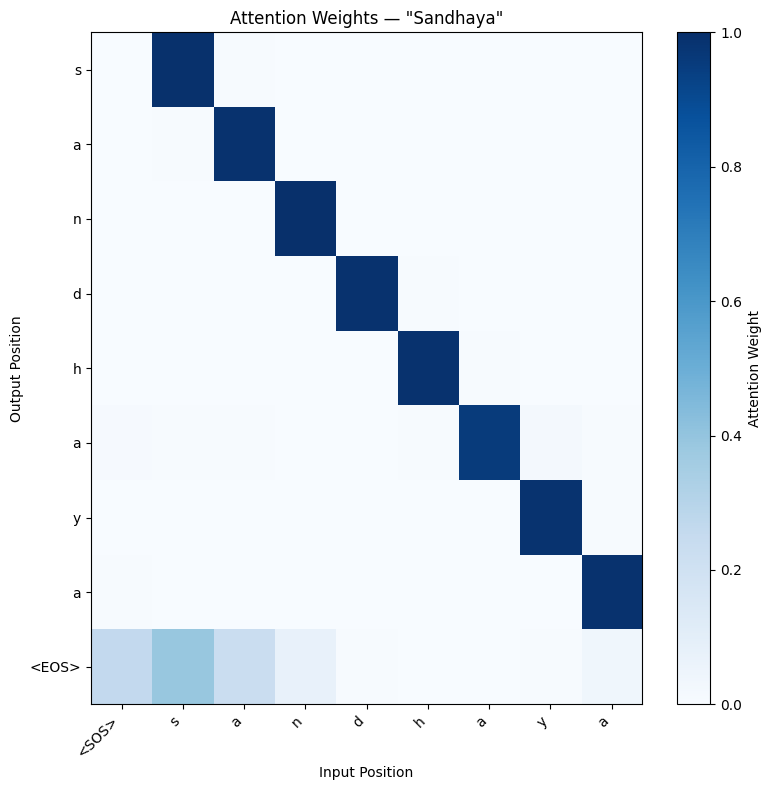

Attention visualisation for: "nazeem"


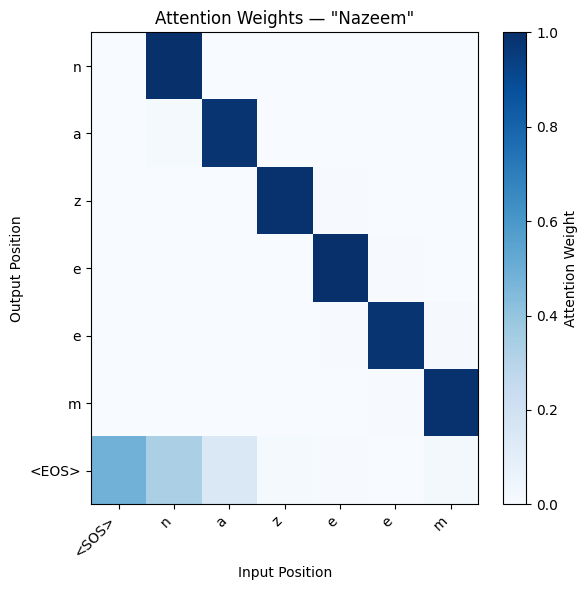

Attention visualisation for: "shahid"


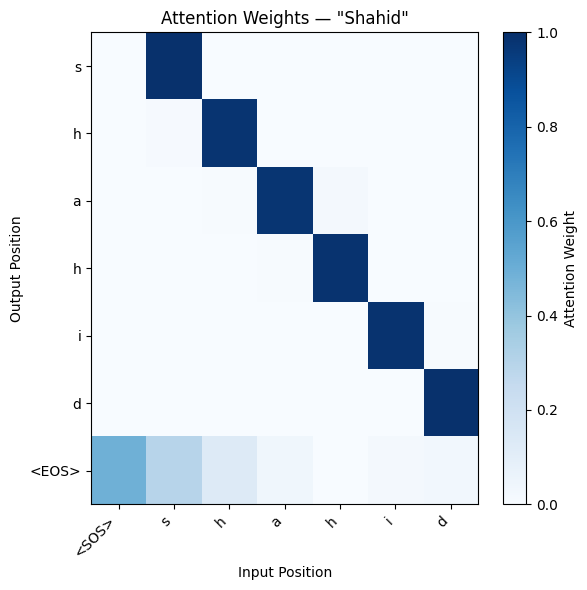

Attention plots saved.


In [22]:
# ── Attention Weight Visualisation (RNN+Attention only) ──────────────────────
@torch.no_grad()
def visualise_attention(model, name, char2idx, idx2char, n_plots=3):
    """
    Visualise the attention weight matrix for a given name.
    Rows = output positions, Columns = input positions
    Bright cells indicate where the model attends when predicting each character.
    """
    model.eval()
    # Encode: <SOS> + name characters
    inp_idx = [SOS_IDX] + [char2idx[c] for c in name if c in char2idx]
    inp     = torch.tensor([inp_idx], dtype=torch.long).to(device)

    logits, _, attn_weights = model(inp)
    # attn_weights: (1, seq_len, seq_len)
    attn = attn_weights[0].cpu().numpy()   # (seq_len, seq_len)

    # x-axis: input chars; y-axis: prediction steps
    input_labels  = ['<SOS>'] + list(name)
    output_labels = list(name) + ['<EOS>']

    fig, ax = plt.subplots(figsize=(max(6, len(name)), max(4, len(name))))
    im = ax.imshow(attn, cmap='Blues', aspect='auto', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Attention Weight')

    ax.set_xticks(range(len(input_labels)))
    ax.set_yticks(range(min(len(output_labels), attn.shape[0])))
    ax.set_xticklabels(input_labels, rotation=45, ha='right')
    ax.set_yticklabels(output_labels[:attn.shape[0]])
    ax.set_xlabel('Input Position')
    ax.set_ylabel('Output Position')
    ax.set_title(f'Attention Weights — "{name.capitalize()}"')

    plt.tight_layout()
    plt.savefig(f'attention_{name}.png', dpi=130)
    plt.show()

# Visualise attention for a few sample training names
sample_names_for_attn = random.sample([n for n in names if 4 <= len(n) <= 8], 3)
for n in sample_names_for_attn:
    print(f'Attention visualisation for: "{n}"')
    visualise_attention(attn_model, n, char2idx, idx2char)

print('Attention plots saved.')

In [23]:
# ── Common Failure Modes Analysis ────────────────────────────────────────────
def analyse_failures(generated, min_len=2, max_len=15):
    """
    Identify and categorise failure cases in generated names.
    Returns summary statistics of failure types.
    """
    failures = defaultdict(list)
    good     = []

    for name in generated:
        if len(name) < min_len:
            failures['too_short'].append(name)
        elif len(name) > max_len:
            failures['too_long'].append(name)
        elif not name.isalpha():
            failures['non_alpha'].append(name)
        else:
            # Check for unrealistic patterns: >3 consecutive same chars
            rep = any(name[i] == name[i+1] == name[i+2]
                      for i in range(len(name)-2))
            # Check for excessive consonant clusters (>4 consonants in a row)
            vowels = set('aeiou')
            consonant_run = 0
            max_consonant_run = 0
            for c in name:
                if c not in vowels:
                    consonant_run += 1
                    max_consonant_run = max(max_consonant_run, consonant_run)
                else:
                    consonant_run = 0

            if rep:
                failures['repetition'].append(name)
            elif max_consonant_run > 4:
                failures['consonant_cluster'].append(name)
            else:
                good.append(name)

    return good, failures

print('\n' + '='*60)
print('FAILURE MODE ANALYSIS')
print('='*60)

for mname, gen in generated_names.items():
    good, failures = analyse_failures(gen)
    total = len(gen)
    print(f'\n{mname}:')
    print(f'  Valid names:       {len(good):>4} / {total} ({len(good)/total*100:.1f}%)')
    for ftype, flist in failures.items():
        print(f'  {ftype:<20}: {len(flist):>4} ({len(flist)/total*100:.1f}%)  '
              f'e.g. {flist[:3]}')


FAILURE MODE ANALYSIS

VanillaRNN:
  Valid names:         63 / 200 (31.5%)
  non_alpha           :  124 (62.0%)  e.g. ['visan chath', 'arin kumar', 'tinay kumar']
  too_long            :   12 (6.0%)  e.g. ['lupender paudhan', 'inder bash kumar', 'anjej kumar santer']
  repetition          :    1 (0.5%)  e.g. ['chaaan']

BLSTM:
  Valid names:          6 / 200 (3.0%)
  too_long            :  194 (97.0%)  e.g. ['omomomomomomomomomom', 'bibibibibibibibibibi', 'yayayayayayayayayaya']

RNN+Attention:
  Valid names:          3 / 200 (1.5%)
  repetition          :   13 (6.5%)  e.g. ['mmm', 'aaaa', 'aaaaa']
  too_long            :  184 (92.0%)  e.g. ['mmmmmmmmmmmmmmmmmmmm', 'aaaaaaaaaaaaaaaaaaaa', 'rmmmmmmmmmmmmmmmmmmm']


In [24]:
# ── Final Summary Table ───────────────────────────────────────────────────────
print('\n' + '='*80)
print('FINAL COMPARISON SUMMARY')
print('='*80)

headers = ['Metric', 'VanillaRNN', 'BLSTM', 'RNN+Attention']
rows = [
    ('Trainable Params',
     f"{count_params(rnn_model):,}",
     f"{count_params(blstm_model):,}",
     f"{count_params(attn_model):,}"),
    ('Embedding Dim',   str(EMBED_DIM),   str(EMBED_DIM),   str(EMBED_DIM)),
    ('Hidden Size',     str(HIDDEN_SIZE), str(HIDDEN_SIZE), str(HIDDEN_SIZE)),
    ('Num Layers',      str(NUM_LAYERS),  str(NUM_LAYERS),  '1'),
    ('Bidirectional',   'No',             'Yes',            'No'),
    ('Attention',       'No',             'No',             'Yes (Bahdanau)'),
    ('Final Val Loss',
     f"{min(all_val_losses['VanillaRNN']):.4f}",
     f"{min(all_val_losses['BLSTM']):.4f}",
     f"{min(all_val_losses['RNN+Attention']):.4f}"),
    ('Novelty Rate (%)',
     f"{eval_results['VanillaRNN']['novelty_rate']:.1f}%",
     f"{eval_results['BLSTM']['novelty_rate']:.1f}%",
     f"{eval_results['RNN+Attention']['novelty_rate']:.1f}%"),
    ('Diversity (%)',
     f"{eval_results['VanillaRNN']['diversity']:.1f}%",
     f"{eval_results['BLSTM']['diversity']:.1f}%",
     f"{eval_results['RNN+Attention']['diversity']:.1f}%"),
    ('Avg Name Length',
     f"{eval_results['VanillaRNN']['avg_len']:.2f}",
     f"{eval_results['BLSTM']['avg_len']:.2f}",
     f"{eval_results['RNN+Attention']['avg_len']:.2f}"),
]

# Print formatted table
col_w = [24, 14, 14, 16]
header_str = '  '.join(h.ljust(col_w[i]) for i, h in enumerate(headers))
print(header_str)
print('-' * len(header_str))
for row in rows:
    print('  '.join(v.ljust(col_w[i]) for i, v in enumerate(row)))
print('='*80)


FINAL COMPARISON SUMMARY
Metric                    VanillaRNN      BLSTM           RNN+Attention   
--------------------------------------------------------------------------
Trainable Params          223,646         2,253,726       478,366         
Embedding Dim             64              64              64              
Hidden Size               256             256             256             
Num Layers                2               2               1               
Bidirectional             No              Yes             No              
Attention                 No              No              Yes (Bahdanau)  
Final Val Loss            1.7706          0.0018          0.0086          
Novelty Rate (%)          92.5%           42.5%           27.5%           
Diversity (%)             99.5%           42.5%           27.5%           
Avg Name Length           10.20           19.46           18.76           


In [25]:
# ── Generate and save 50 representative samples per model for the report ──────
print('\nRepresentative Sample Names (50 per model, for report):')

for mname, gen in generated_names.items():
    # Select 50 names: avoid duplicates, prefer names of reasonable length (3-10 chars)
    good_names = list(set([n for n in gen if 3 <= len(n) <= 10]))
    random.shuffle(good_names)
    report_sample = good_names[:50]

    fname = f'ReportSample_{mname.replace(" ","").replace("+","Plus")}.txt'
    with open(fname, 'w') as f:
        f.write(f'# {mname} — Representative Generated Names\n\n')
        for i, n in enumerate(report_sample, 1):
            f.write(f'{i:3d}. {n.capitalize()}\n')
    print(f'  Saved {len(report_sample)} names → {fname}')

print('\nAll outputs saved!')
print('\nFiles produced:')
print('  best_rnn.pt / best_blstm.pt / best_attn.pt  — model checkpoints')
print('  GeneratedNames_*.txt                         — 200 generated names per model')
print('  ReportSample_*.txt                           — 50 curated names for report')
print('  loss_curves_p2.png                           — training/val loss curves')
print('  eval_metrics_p2.png                          — novelty/diversity bar charts')
print('  name_length_dist.png                         — length distributions')
print('  attention_*.png                              — attention weight heatmaps')


Representative Sample Names (50 per model, for report):
  Saved 50 names → ReportSample_VanillaRNN.txt
  Saved 0 names → ReportSample_BLSTM.txt
  Saved 10 names → ReportSample_RNNPlusAttention.txt

All outputs saved!

Files produced:
  best_rnn.pt / best_blstm.pt / best_attn.pt  — model checkpoints
  GeneratedNames_*.txt                         — 200 generated names per model
  ReportSample_*.txt                           — 50 curated names for report
  loss_curves_p2.png                           — training/val loss curves
  eval_metrics_p2.png                          — novelty/diversity bar charts
  name_length_dist.png                         — length distributions
  attention_*.png                              — attention weight heatmaps
